In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import skimage.io as skio

# Q2: Please reduce the noise in the following image with Fourier Transform.

(-0.5, 511.5, 511.5, -0.5)

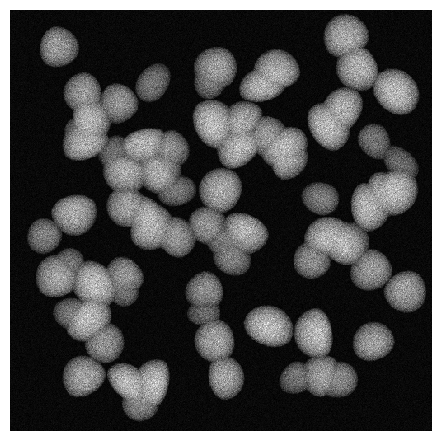

In [2]:
image = skio.imread('image_denoise.png')
skio.imshow(image)
plt.axis('off')

In [3]:
from scipy.fft import fft2, ifft2

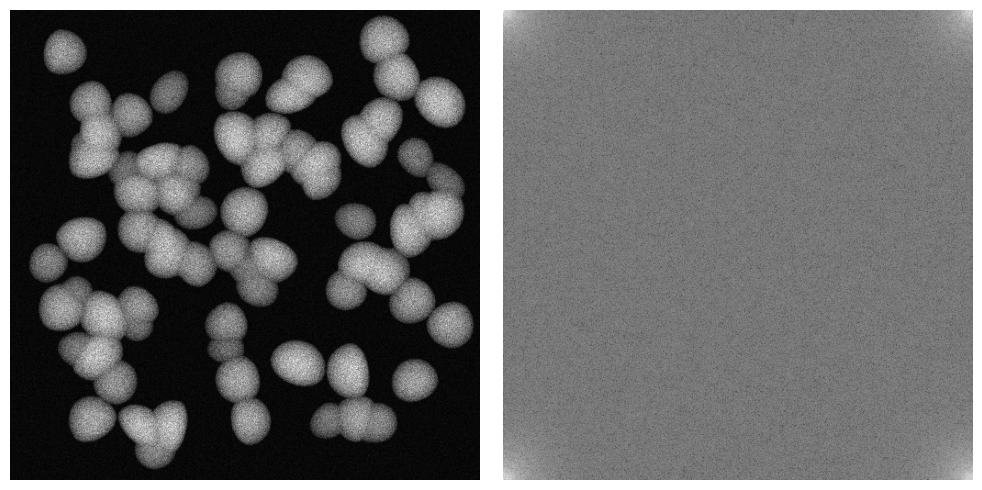

In [4]:
from matplotlib.colors import LogNorm
image_fft = fft2(image)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].axis('off')

ax[1].imshow(np.abs(image_fft), norm=LogNorm(vmin=5), cmap='gray')
ax[1].axis('off')
plt.tight_layout()
plt.show()

/opt/conda/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


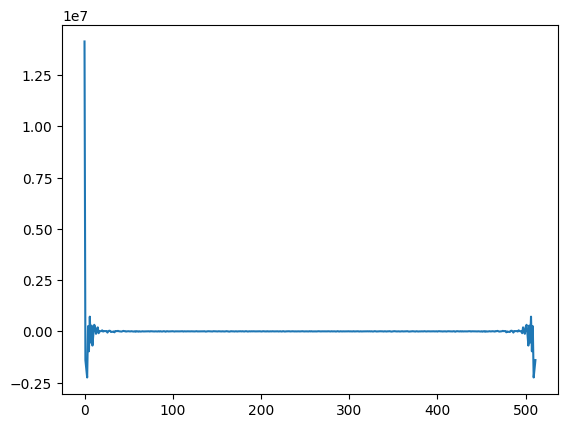

In [5]:
plt.plot(image_fft[0,:])

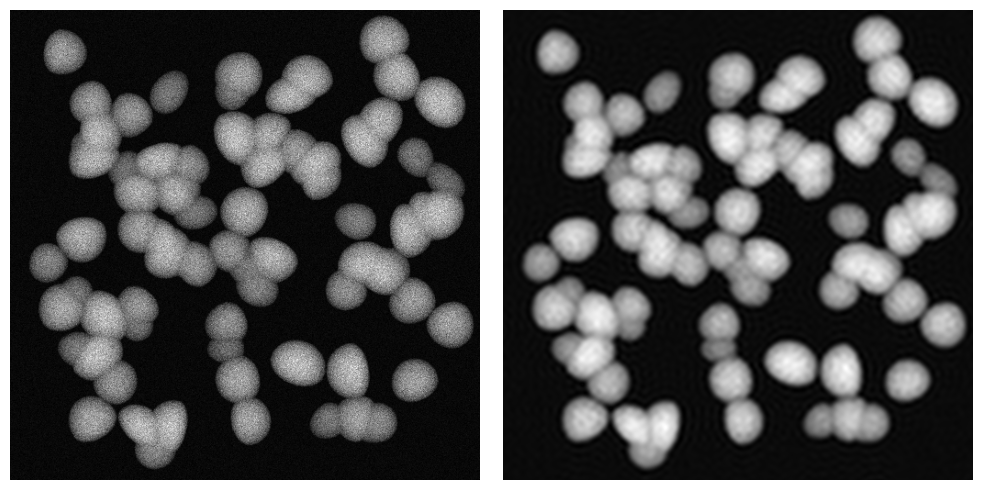

In [6]:
r, c = image_fft.shape
keep_fraction = 0.1
image_fft[int(r*keep_fraction):int(r*(1-keep_fraction)+1)] = 0
image_fft[:, int(c*keep_fraction):int(c*(1-keep_fraction)+1)] = 0

image_ifft = ifft2(image_fft)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image, cmap='gray')
ax[0].axis('off')

ax[1].imshow(np.abs(image_ifft), cmap='gray')
ax[1].axis('off')
plt.tight_layout()
plt.show()

In [7]:
def gkernel(shape, sig=2):
    """\
    Gaussian Kernel Creator via given length and sigma
    """

    ax = np.linspace(-(shape[0] - 1) / 2., (shape[0] - 1) / 2., shape[0])
    ay = np.linspace(-(shape[1] - 1) / 2., (shape[1] - 1) / 2., shape[1])
    xx, yy = np.meshgrid(ax, ay)

    kernel = np.exp(-0.5 * (np.square(xx) + np.square(yy)) / np.square(sig))

    return (kernel-np.min(kernel)) / (np.max(kernel)-np.min(kernel))

(-0.5, 511.5, 511.5, -0.5)

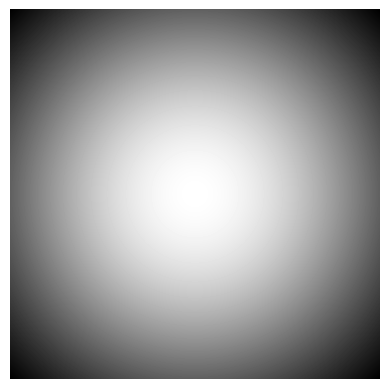

In [8]:
fft_mask = gkernel(image.shape, sig=256)
plt.imshow(fft_mask, cmap='gray')
plt.axis('off')

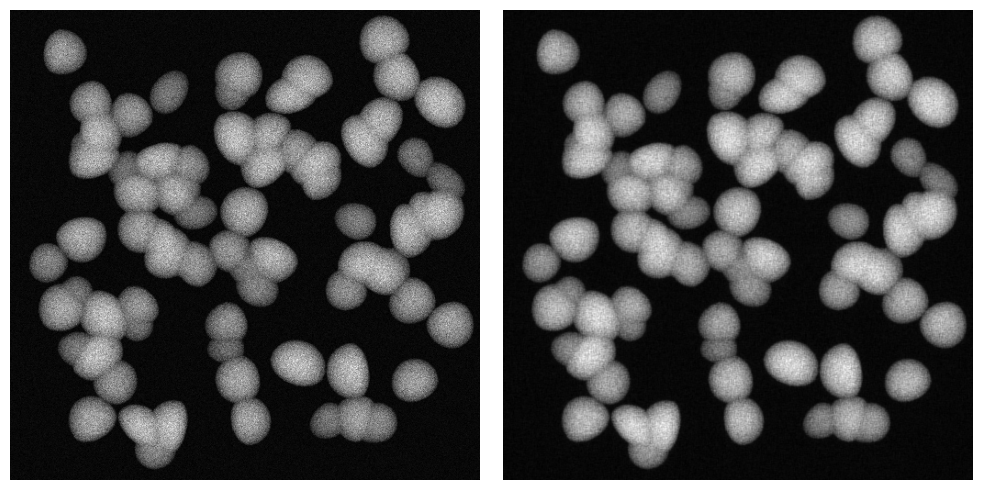

In [9]:
image_fft = fft2(image)
image_fft = image_fft * (1-fft_mask)
image_ifft = ifft2(image_fft)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].axis('off')

ax[1].imshow(np.abs(image_ifft), cmap='gray')
ax[1].axis('off')
plt.tight_layout()
plt.show()

# Q3: Please improve the quality (noise, contrast) of the following image with Fourier Transform.

Range of image:  50 255
Shape of image:  (512, 512)


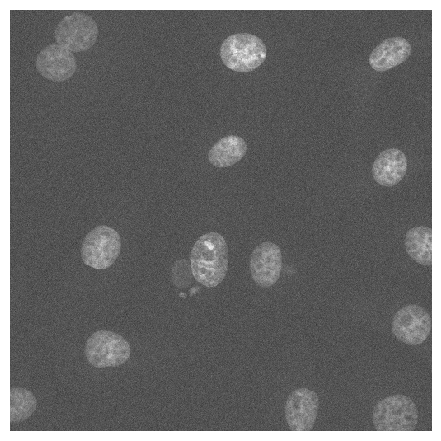

In [10]:
image = skio.imread('image_contrast.png')
skio.imshow(image)
plt.axis('off')
print('Range of image: ', np.min(image), np.max(image))
print('Shape of image: ', np.shape(image))

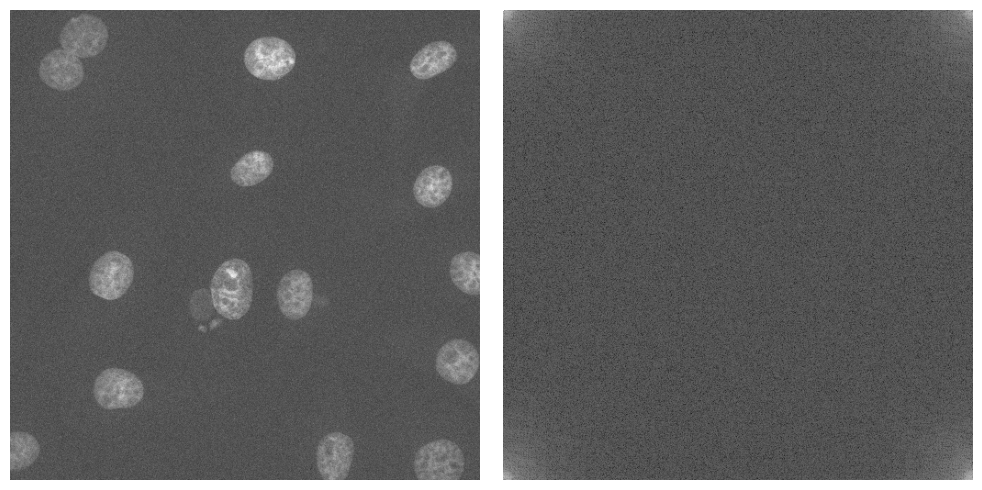

In [11]:
image_fft = fft2(image)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray', vmin=0)
ax[0].axis('off')

ax[1].imshow(np.abs(image_fft), norm=LogNorm(vmin=50), cmap='gray')
ax[1].axis('off')
plt.tight_layout()
plt.show()

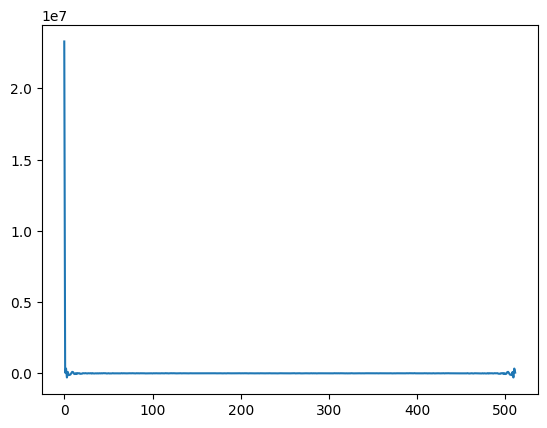

In [12]:
plt.plot(image_fft[0,:])

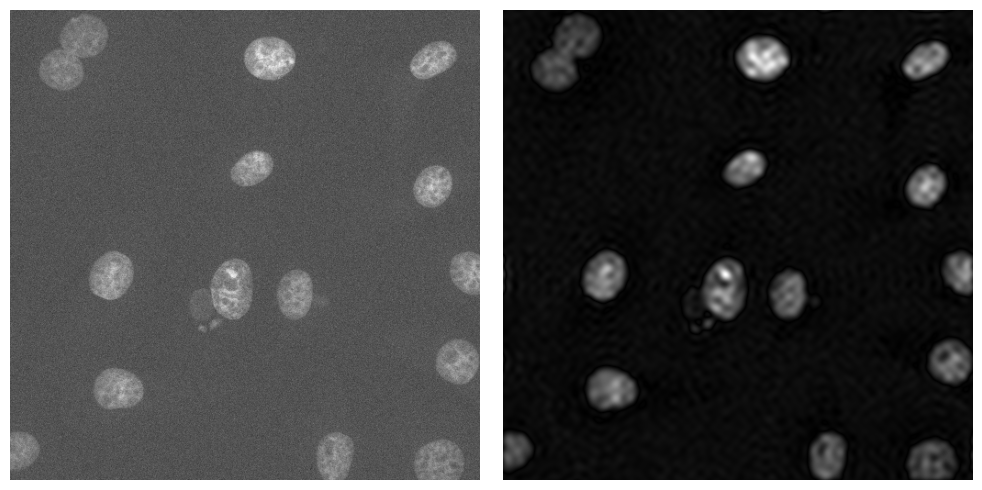

In [13]:
image_fft = fft2(image)
fft_mask = np.zeros_like(image)

r, c = image_fft.shape
remove_fraction = 1
fft_mask[remove_fraction:int(r-remove_fraction+1), :] = 1
fft_mask[:, remove_fraction:int(c-remove_fraction+1)] = 1

image_fft = image_fft * fft_mask


fft_mask = np.ones_like(image)
keep_fraction = 40
fft_mask[keep_fraction:int(r-keep_fraction+1), :] = 0
fft_mask[:, keep_fraction:int(c-keep_fraction+1)] = 0

image_fft = image_fft * fft_mask

image_ifft = ifft2(image_fft)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray', vmin=0)
ax[0].axis('off')

ax[1].imshow(np.abs(image_ifft), cmap='gray', vmin=0)
ax[1].axis('off')
plt.tight_layout()
plt.show()

# Q5: Please perform k-means clustering for the following image based on 3-5 first-order statistical features.

(-0.5, 1349.5, 1484.5, -0.5)

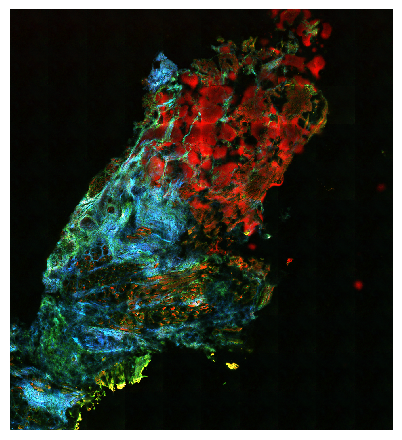

In [15]:
image = skio.imread('example_image.png')

skio.imshow(image)
plt.axis('off')

In [16]:
! pip install SimpleITK
! pip install pyradiomics
import SimpleITK as sitk

from radiomics import featureextractor

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 571.9 kB/s eta 0:00:0000:0100:01
  Using cached pyradiomics-3.1.0.tar.gz (34.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Discarding https://files.pythonhosted.org/packages/03/c1/20fc2c50ab1e3304da36d866042a1905a2b05a1431ece35448ab6b4578f2/pyradiomics-3.1.0.tar.gz (from https://pypi.org/simple/pyradiomics/): Requested pyradiomics from https://files.pythonhosted.org/packages/03/c1/20fc2c50ab1e3304da36d866042a1905a2b05a1431ece35448ab6b4578f2/pyradiomics-3.1.0.tar.gz has inconsistent version: expected '3.1.0', but metadata has '3.0.1a1'
  Using cached pyradiomics-3.0.1-cp310-cp310-linux_x86_64.whl
  Using cached pykwalify-1.8.0-py2.py3-none-any.whl (24 kB)
  Using cached docopt-0.6.2-py2.py3-none-any.whl


In [17]:
fea_firstorder = ['Mean', 'Skewness', 'Entropy', 'Kurtosis', 'Uniformity']

extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.disableAllFeatures()
# extractor.enableFeatureClassByName('firstorder')
extractor.enableFeaturesByName(firstorder=fea_firstorder)   ### https://pyradiomics.readthedocs.io/en/latest/features.html#radiomics.firstorder.RadiomicsFirstOrder
    

im_shape = image.shape

features_all = []
feature_names = []
for i in range(im_shape[2]):
    
    channel = np.reshape(image[:,:,i], [im_shape[0], im_shape[1], 1])
    mask = np.zeros_like(channel)
    mask[channel > 20] = 1.0
    
    channel = sitk.GetImageFromArray(channel)
    mask = sitk.GetImageFromArray(mask)
    
    features = extractor.computeFeatures(channel, mask, 'original', voxelBased=True, kernelRadius=1)  ### 2*kernelRadius + 1
    for featureName in features.keys():
        val = sitk.GetArrayFromImage(features[featureName])
        features_all.append(val/np.max(val))
        feature_names = np.append(feature_names, featureName)

In [18]:
features_all = np.concatenate(features_all, axis=-1)
features_all.shape

(1485, 1350, 15)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


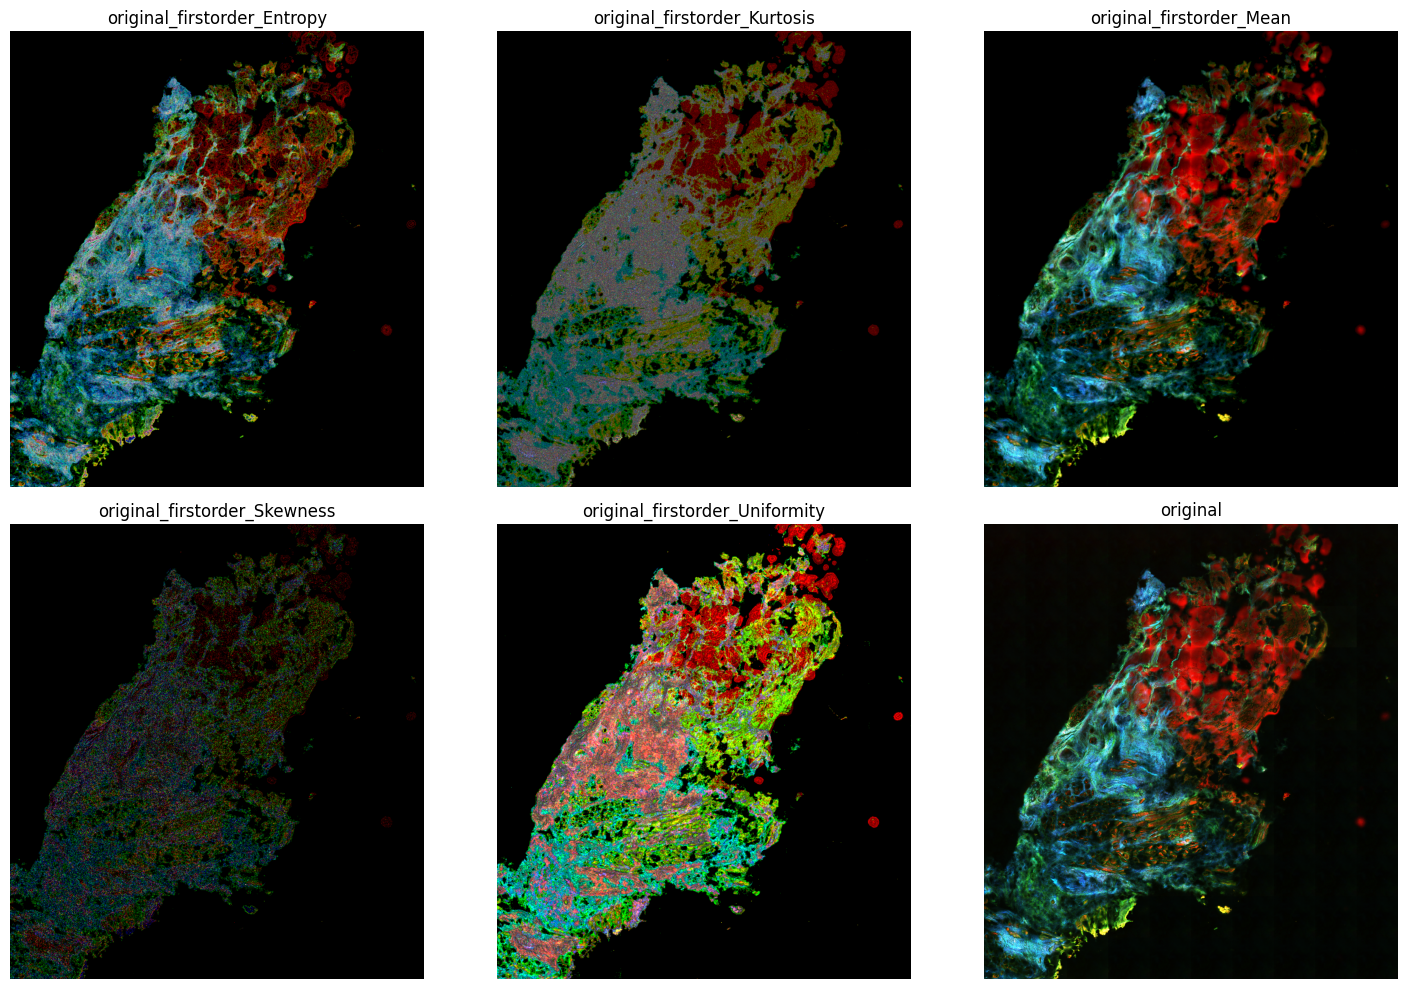

In [19]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
for i, fea in enumerate(np.unique(feature_names)):
    ax[i//3, i%3].imshow(features_all[:,:, feature_names==fea])
    ax[i//3, i%3].axis('off')
    ax[i//3, i%3].set_title(fea)
ax[1, 2].imshow(image)
ax[1, 2].axis('off')
ax[1, 2].set_title('original')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.cluster import KMeans

features_all_2d = np.reshape(features_all, (im_shape[0]*im_shape[1], 15))
n_cluster = 5  ## k = 3
kmeans_fea = KMeans(n_clusters=n_cluster, random_state=0).fit(features_all_2d)
cluster_fea = kmeans_fea.labels_
cluster_fea.shape

(2004750,)

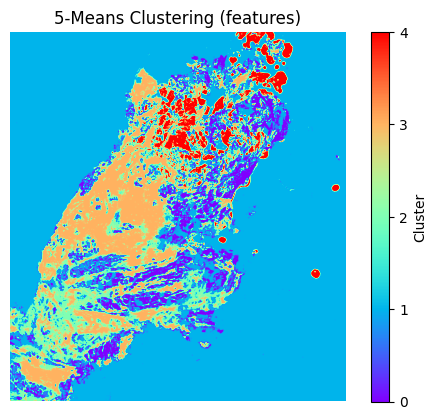

In [21]:
### fold cluster results back into image and display the results
cluster_fea2D = cluster_fea.reshape((im_shape[0], im_shape[1]) )
r_cluster = plt.imshow(cluster_fea2D, cmap='rainbow')
plt.axis('off')
cbar = plt.colorbar(r_cluster, ticks=np.arange(n_cluster))
cbar.set_label("Cluster")
plt.title(str(n_cluster)+ '-Means Clustering (features)')
plt.show()

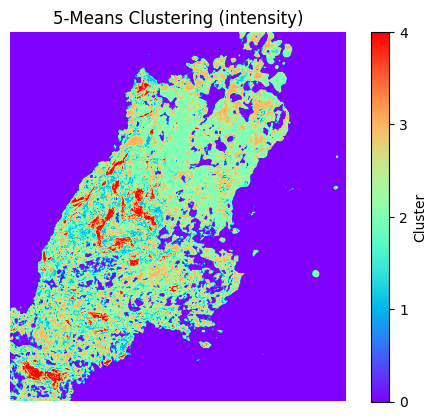

In [22]:
### clustering based on image intensities
image_2d = image.reshape((im_shape[0]*im_shape[1], 3))

### do k-means
kmeans_im = KMeans(n_clusters=n_cluster, random_state=0).fit(image_2d)
cluster_im = kmeans_im.labels_
cluster_im.shape

### fold cluster results back into image and display the results
cluster_im2D = cluster_im.reshape( (im_shape[0], im_shape[1]) )
r_cluster = plt.imshow(cluster_im2D, cmap='rainbow')
plt.axis('off')
cbar = plt.colorbar(r_cluster, ticks=np.arange(n_cluster))
cbar.set_label("Cluster")
plt.title(str(n_cluster)+ '-Means Clustering (intensity)')
plt.show()

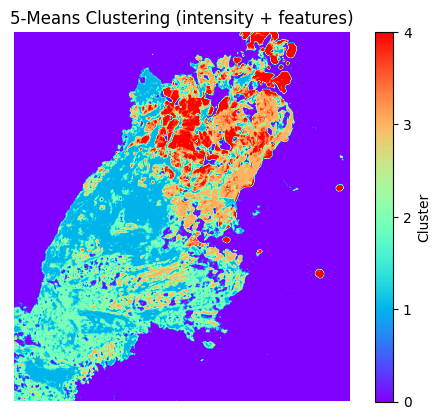

In [23]:
im_feature = np.concatenate([image_2d/255.0, features_all_2d], axis=-1)   ### normalize image to (0,1)

### do k-means
kmeans_im_fea = KMeans(n_clusters=n_cluster, random_state=0).fit(im_feature)
cluster_im_fea = kmeans_im_fea.labels_

### fold cluster results back into image and display the results
cluster_im_fea2D = cluster_im_fea.reshape((im_shape[0], im_shape[1]) )
r_cluster = plt.imshow(cluster_im_fea2D, cmap='rainbow')
plt.axis('off')
cbar = plt.colorbar(r_cluster, ticks=np.arange(n_cluster))
cbar.set_label("Cluster")
plt.title(str(n_cluster)+ '-Means Clustering (intensity + features)')
plt.show()

/tmp/ipykernel_369/4103287025.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


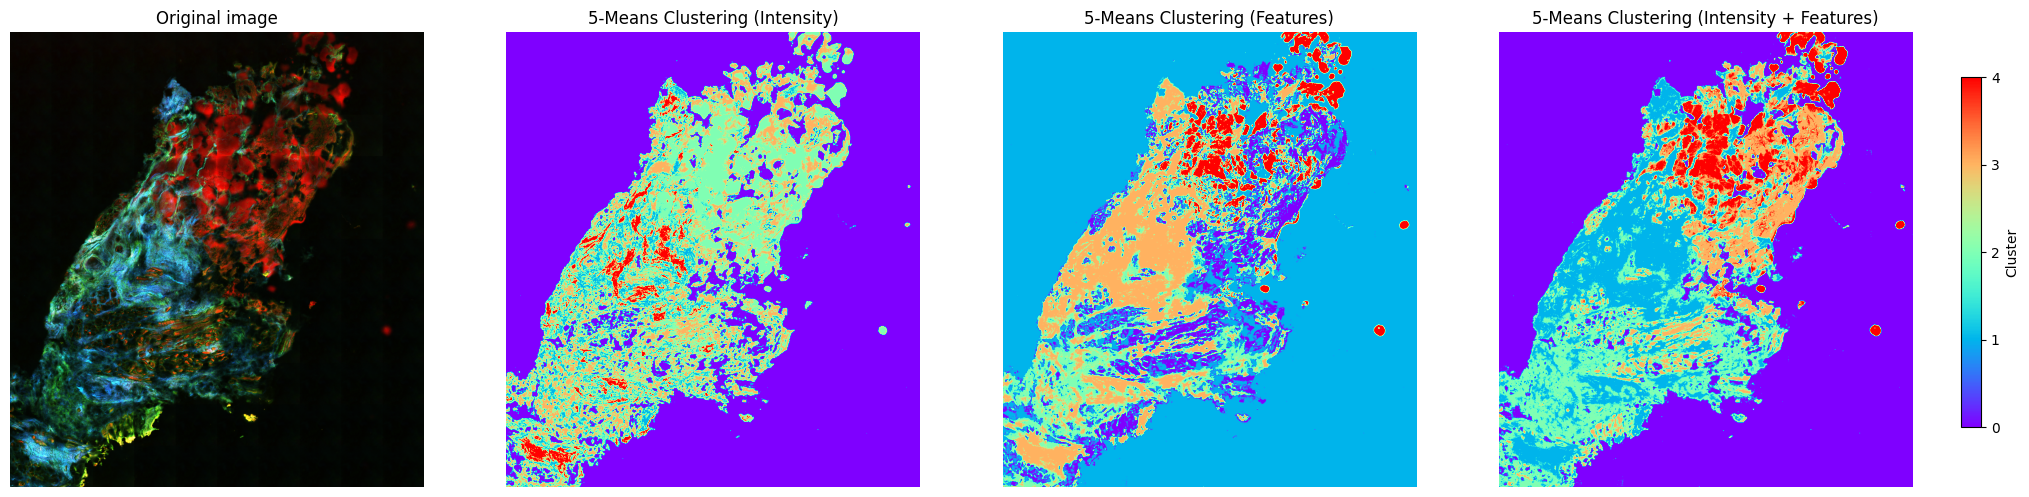

In [24]:
### plot everything in one figure
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image)
ax[0].axis('off')
ax[0].set_title('Original image')

r_cluster = ax[1].imshow(cluster_im2D, cmap='rainbow')
ax[1].axis('off')
ax[1].set_title(str(n_cluster)+ '-Means Clustering (Intensity)')

r_cluster = ax[2].imshow(cluster_fea2D, cmap='rainbow')
ax[2].axis('off')
ax[2].set_title(str(n_cluster)+ '-Means Clustering (Features)')

r_cluster = ax[3].imshow(cluster_im_fea2D, cmap='rainbow')
ax[3].axis('off')
ax[3].set_title(str(n_cluster)+ '-Means Clustering (Intensity + Features)')

cbar_ax = fig.add_axes([1, 0.15, 0.01, 0.7])
cbar = plt.colorbar(r_cluster, ticks=np.arange(n_cluster), shrink=0.75, cax=cbar_ax)
cbar.set_label("Cluster")

plt.tight_layout()
plt.show()